# Week 3 Assignment

## Import data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as train_test_split

In [3]:
df = pd.read_csv("week3.csv", header=None, comment="#")

print(df.head())

# Extract columns
X1 = df.iloc[:, 0]
X2 = df.iloc[:, 1]
X = np.column_stack((X1, X2))
y = df.iloc[:, 2]

#print(X, y)

      0     1         2
0 -0.55 -0.04  0.194909
1  0.67 -0.68 -0.672511
2 -0.05  0.42  0.418637
3 -0.34 -0.08  0.126848
4 -0.10  0.89  0.764855


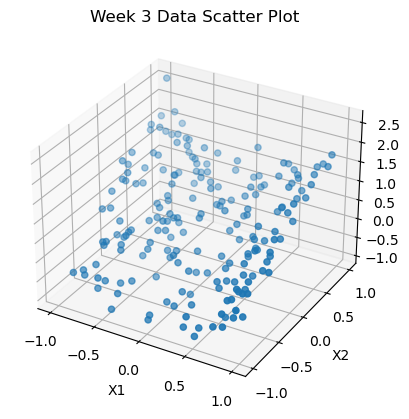

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:, 0], X[:, 1], y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('Week 3 Data Scatter Plot')

plt.show() 


In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)

X_poly = poly.fit_transform(X)
print(X_poly)
feature_names = poly.get_feature_names_out(['x1', 'x2'])
print(feature_names)

[[ 1.00000000e+00 -5.50000000e-01 -4.00000000e-02 ... -1.93600000e-05
  -1.40800000e-06 -1.02400000e-07]
 [ 1.00000000e+00  6.70000000e-01 -6.80000000e-01 ... -1.41148525e-01
   1.43255219e-01 -1.45393357e-01]
 [ 1.00000000e+00 -5.00000000e-02  4.20000000e-01 ...  1.85220000e-04
  -1.55584800e-03  1.30691232e-02]
 ...
 [ 1.00000000e+00 -7.00000000e-02  8.70000000e-01 ...  3.22666470e-03
  -4.01028327e-02  4.98420921e-01]
 [ 1.00000000e+00  1.60000000e-01  2.10000000e-01 ...  2.37081600e-04
   3.11169600e-04  4.08410100e-04]
 [ 1.00000000e+00  8.20000000e-01  8.60000000e-01 ...  4.27684054e-01
   4.48546691e-01  4.70427018e-01]]
['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2' 'x1^3' 'x1^2 x2' 'x1 x2^2' 'x2^3'
 'x1^4' 'x1^3 x2' 'x1^2 x2^2' 'x1 x2^3' 'x2^4' 'x1^5' 'x1^4 x2'
 'x1^3 x2^2' 'x1^2 x2^3' 'x1 x2^4' 'x2^5']


In [16]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

lasso = {}
for c in [1, 1/100, 1/10000, 1/1000000]:
    model = Lasso(alpha=c)
    lasso[c] = model.fit(X_poly, y)
    print(f"Lasso model with alpha={c}:")
    print(f"  Coefficients: {model.coef_}")
    print(f"  Intercept: {model.intercept_}")

print(feature_names)

Lasso model with alpha=1:
  Coefficients: [ 0. -0.  0.  0. -0.  0. -0.  0. -0.  0.  0. -0.  0. -0.  0. -0.  0. -0.
  0. -0.  0.]
  Intercept: 0.428836300610418
Lasso model with alpha=0.01:
  Coefficients: [ 0.         -0.          0.95337202  0.85859803 -0.          0.
 -0.          0.         -0.          0.          0.         -0.
  0.         -0.          0.         -0.          0.         -0.
  0.         -0.          0.        ]
  Intercept: 0.043188460286533226
Lasso model with alpha=0.0001:
  Coefficients: [ 0.         -0.01287651  1.14101991  0.99703421  0.09149603  0.08912013
  0.02124842 -0.25185638 -0.01611346 -0.420606    0.03465027 -0.04182879
 -0.18968571 -0.14863845  0.03052455  0.01467268  0.06926906  0.09754415
  0.29903342 -0.10855878  0.24973267]
  Intercept: -0.03303339822031398
Lasso model with alpha=1e-06:
  Coefficients: [ 0.         -0.0109561   1.22120334  1.03030857  0.13074143  0.11721436
  0.03603269 -0.42161315 -0.0926717  -0.65198107  0.01130682 -0.0759209

c:\Users\usuario\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.991e-01, tolerance: 8.732e-03
  model = cd_fast.enet_coordinate_descent(


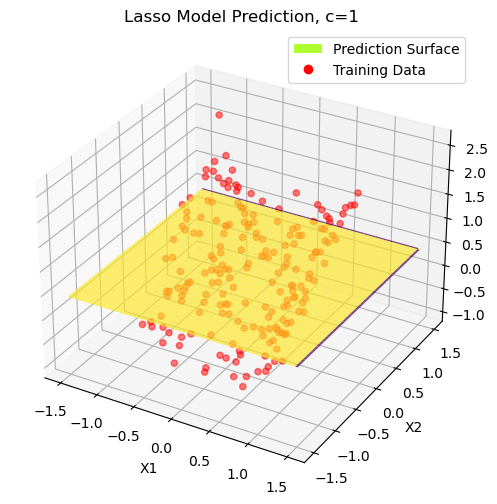

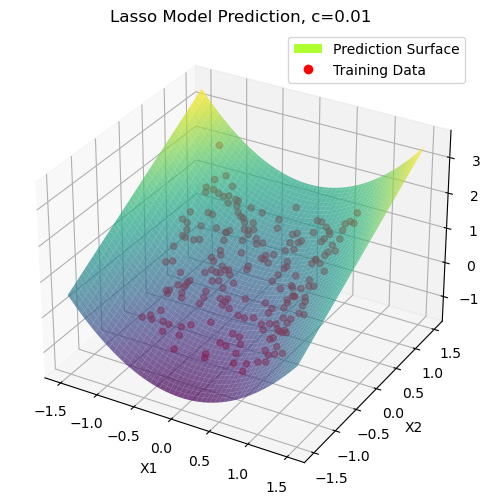

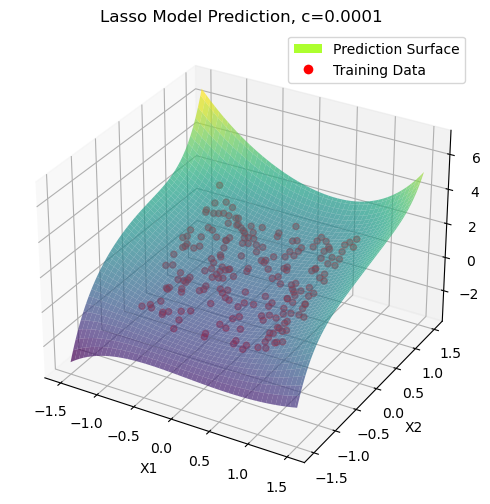

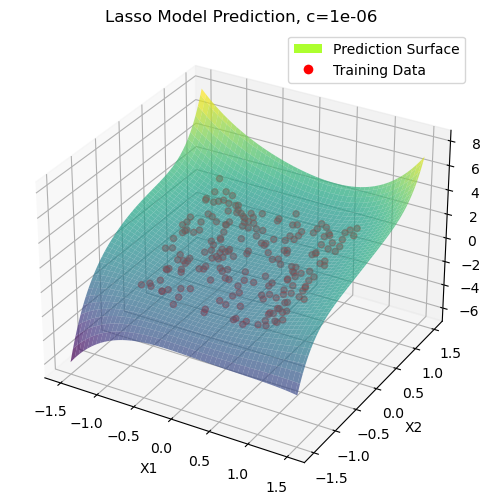

In [58]:

# iii) Plot data with model predictions
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_model_surface(ax, model, poly):
    grid = np.linspace(-1.5, 1.5, 100)
    X1, X2 = np.meshgrid(grid, grid)
    Y_pred = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            poly_features = poly.transform([[X1[i, j], X2[i, j]]])
            Y_pred[i, j] = model.predict(poly_features)[0]

    ax.plot_surface(X1, X2, Y_pred, cmap='viridis', alpha=0.7)

for c, model in lasso.items():
    y_pred = model.predict(X_poly)
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='r', alpha=0.5, s=20)
    plot_model_surface(ax, model, poly)

    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    ax.set_title(f'Lasso Model Prediction, c={c}')


    legend_elements = [
        Patch(facecolor='#ADFF2F', label='Prediction Surface'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=8, label='Training Data')
    ]
    ax.legend(handles=legend_elements)

plt.show()

Ridge model with alpha=1:
  Coefficients: [ 0.         -0.01218255  0.9053258   0.65593886  0.03076776  0.04354395
  0.02405616  0.04828868 -0.03488741  0.07897025  0.31465665 -0.00193913
 -0.02301599 -0.08381279  0.02027282  0.02344455 -0.01914493  0.04025078
 -0.00620629 -0.05721942 -0.00823753]
  Intercept: 0.03001820913850972
Ridge model with alpha=10:
  Coefficients: [ 0.         -0.0141626   1.08888989  0.92309345  0.1038594   0.07960366
  0.03123188 -0.19507141 -0.04059577 -0.27769271  0.10813908 -0.05283459
 -0.17571544 -0.1563563   0.03731522  0.00804112  0.06461903  0.12581456
  0.22214772 -0.10547965  0.15956726]
  Intercept: -0.021915982826609448
Ridge model with alpha=100:
  Coefficients: [ 0.         -0.01203916  1.19996661  1.01644887  0.12745887  0.11093356
  0.03641058 -0.38645374 -0.08177116 -0.5887057   0.02389131 -0.07345359
 -0.23481485 -0.17993505  0.02293362 -0.0054868   0.16643584  0.18190522
  0.39262985 -0.08605085  0.36732656]
  Intercept: -0.0384650836367594

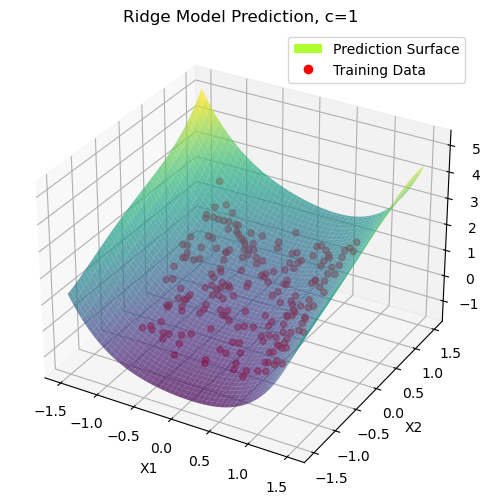

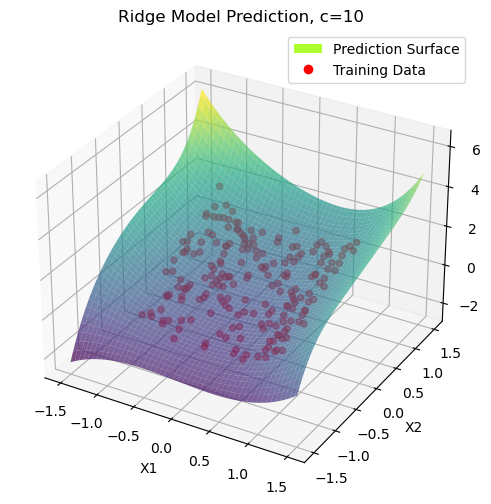

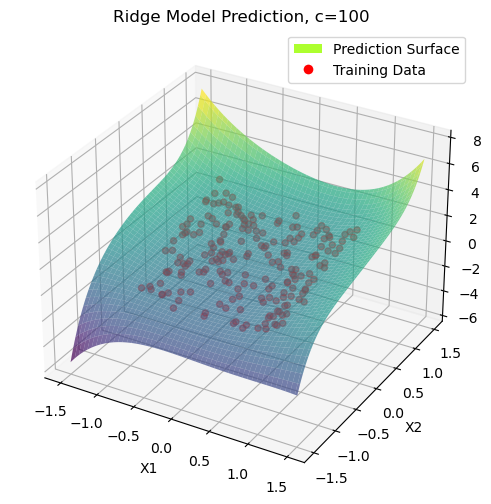

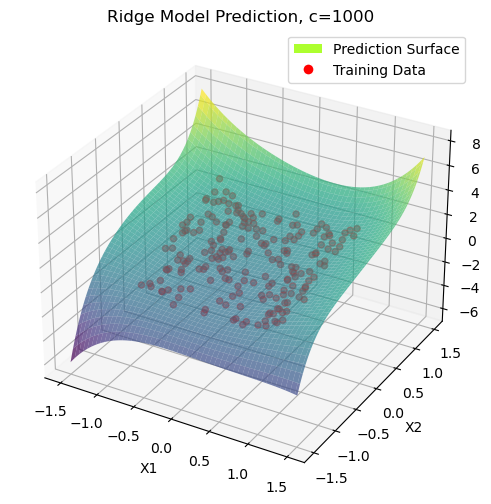

In [75]:
# e) Rigde Regression
from sklearn.linear_model import Ridge

ridge = {}
C = [1, 10, 100, 1000]
for c in C:
    model = Ridge(alpha=1/c)
    ridge[c] = model.fit(X_poly, y)
    print(f"Ridge model with alpha={c}:")
    print(f"  Coefficients: {model.coef_}")
    print(f"  Intercept: {model.intercept_}")                      


# iii) Plot data with model predictions

def plot_model_surface(ax, model, poly):
    grid = np.linspace(-1.5, 1.5, 100)
    X1, X2 = np.meshgrid(grid, grid)
    Y_pred = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            poly_features = poly.transform([[X1[i, j], X2[i, j]]])
            Y_pred[i, j] = model.predict(poly_features)[0]

    ax.plot_surface(X1, X2, Y_pred, cmap='viridis', alpha=0.7)

for c, model in ridge.items():
    y_pred = model.predict(X_poly)
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='r', alpha=0.5, s=20)
    plot_model_surface(ax, model, poly)

    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    ax.set_title(f'Ridge Model Prediction, c={c}')


    legend_elements = [
        Patch(facecolor='#ADFF2F', label='Prediction Surface'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=8, label='Training Data')
    ]
    ax.legend(handles=legend_elements)

plt.show()


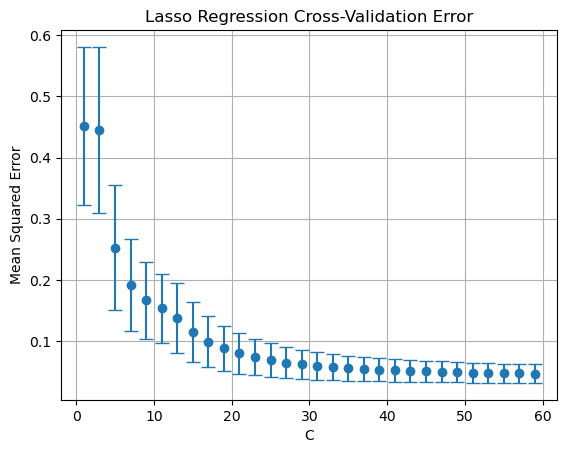

In [94]:
# a) Error on Lasso regression with cross-validation
from sklearn.model_selection import cross_val_score
import statistics as stats

cv_scores = []
C = np.arange(1, 60, 2)
for c in C:
    model = Lasso(alpha=1/c)
    cv_scores.append(cross_val_score(model, X_poly, y, cv=5, scoring='neg_mean_squared_error'))

mean = [stats.mean(-score) for score in cv_scores]
std = [stats.stdev(score) for score in cv_scores]

plt.errorbar(C, mean, yerr=std, fmt='o', capsize=5)
plt.xlabel('C')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression Cross-Validation Error')
plt.grid()
plt.show()

0.04767221161028675 7


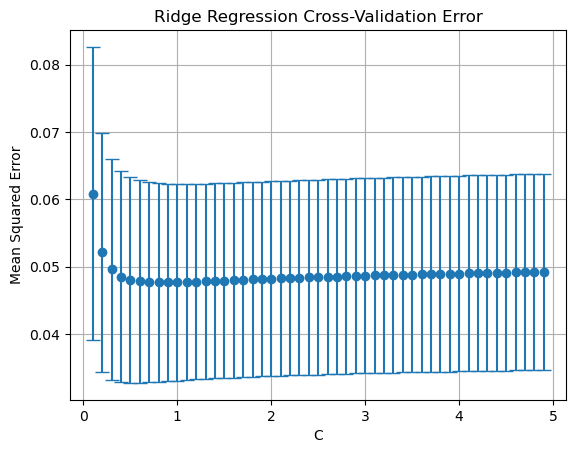

In [ ]:
cv_scores = []
C = np.arange(0.1, 5, 0.1)
for c in C:
    model = Ridge(alpha=1/c)
    cv_scores.append(cross_val_score(model, X_poly, y, cv=5, scoring='neg_mean_squared_error'))

mean = [stats.mean(-score) for score in cv_scores]
std = [stats.stdev(score) for score in cv_scores]

plt.errorbar(C, mean, yerr=std, fmt='o', capsize=5)
plt.xlabel('C')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression Cross-Validation Error')
plt.grid()
plt.show()